# Limpieza de Tablas 

## Problema: Optimizar inventario reduciendo errores en la predicción de demanda diaria.

- Problema:\
Exceso o escasez de inventario debido a variabilidad e incertidumbre en la demanda diaria.

1. Objetivo analítico\
Entender patrones de demanda (estacionalidad, precio, volatilidad).

2. Objetivo predictivo\
Construir un modelo de forecasting para estimar ventas a 28 días.

3. Impacto esperado\
Mejor planificación, menor desperdicio, mayor disponibilidad en productos clave.

- Hipótesis:

1. La demanda es altamente intermitente.

2. Los productos presentan alta volatilidad.

3. Las ventas aumentan el fin de semana.

4. La demanda es sensible al precio


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Cargando Tablas

In [2]:
calendar = pd.read_csv("../data/calendar.csv")
sales_evaluation = pd.read_csv("../data/sales_train_evaluation.csv")
sales_validation = pd.read_csv("../data/sales_train_validation.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")
sell_prices = pd.read_csv("../data/sell_prices.csv")

## Limpieza de Tabla Calendar 

In [3]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


### Revisión de duplicados, nulos y tipos de datos, 

In [4]:
# nulos y duplicados
print(calendar.duplicated().sum())
calendar.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [5]:
# Cambiando de tipo de dato date
calendar['date'] = pd.to_datetime(calendar['date'])

Creamos una variable binaria, True -> 1 y False -> 0, para saber si hubo alguna festividad

In [6]:
#Creamos una variable binaria, porque queremos saber si hubo alguna festividad en esos dias

calendar["has_event"] = (calendar["event_name_1"].notna() | calendar["event_name_2"].notna()).astype(int)

In [7]:
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1,0
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0,0


## sales_train_validation
#### Prototipo con la tienda 'CA_1'

In [8]:
## Voy a filtrar por 'store_id' == 'CA_1' para crear un prototipo porque serian muchas filas y seria
# el primer vistazo a los datos 
sales_small = sales_validation[sales_validation['store_id'] == 'CA_1']

In [9]:
sales_small.shape

(3049, 1919)

In [10]:
# Para poder hacer el merge entre sales_Validation y calendar, tengo que pasar de formato de ancho a largo
# a la tabla sales_validation

sales_long = sales_small.melt(
    id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
    var_name = "d", 
    value_name = "sales")


In [11]:
sales_long

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...,...
5832732,FOODS_3_823_CA_1_validation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1913,1
5832733,FOODS_3_824_CA_1_validation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1913,0
5832734,FOODS_3_825_CA_1_validation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1913,2
5832735,FOODS_3_826_CA_1_validation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1913,0


### Revisando los nuevos valores de la tabla sales_long 

In [12]:
sales_long["sales"].describe()

count    5.832737e+06
mean     1.319829e+00
std      4.058652e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      6.480000e+02
Name: sales, dtype: float64

La mediana es 0 -> el 50% de las observaciones tienen ventas = 0. Muchos días sin venta por producto.\
La media es 1.32 -> promedio muy bajo, indica que la mayoria de productos venden poco por día.\
Alta desviación estándar \
std= 4.05 con media de 1.32 -> alta variabilidad, distribución muy sesgada\
Maximo = 648 existen picos grandes de ventas\
probablemente: promociones, eventos, productos populares.

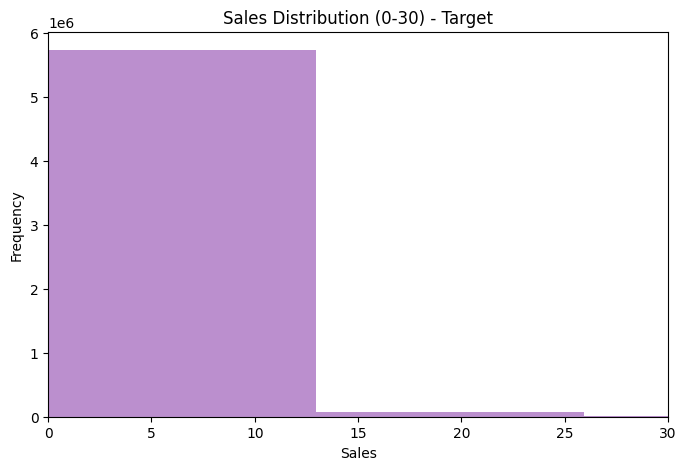

In [13]:
plt.figure(figsize=(8,5))
plt.hist(sales_long["sales"], bins=50, color='#BB8FCE')
plt.title("Sales Distribution (0-30) - Target")
plt.xlim(0,30)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Este target puede requerir transformación mas adelante

In [14]:
(sales_long["sales"] == 0).mean() 
# porcentaje de dias sin venta es de 63% 

0.6394733724493321

## Hacemos merge entre Calendar y sales_long (sales_validation) -> cal_sal

In [15]:
cal_sal = sales_long.merge(calendar, on='d', how='left')

In [16]:
cal_sal

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832732,FOODS_3_823_CA_1_validation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1913,1,2016-04-24,11613,...,4,2016,NaN,NaN,NaN,NaN,0,0,0,0
5832733,FOODS_3_824_CA_1_validation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,4,2016,NaN,NaN,NaN,NaN,0,0,0,0
5832734,FOODS_3_825_CA_1_validation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1913,2,2016-04-24,11613,...,4,2016,NaN,NaN,NaN,NaN,0,0,0,0
5832735,FOODS_3_826_CA_1_validation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,4,2016,NaN,NaN,NaN,NaN,0,0,0,0


#### Ventas totales por dias 

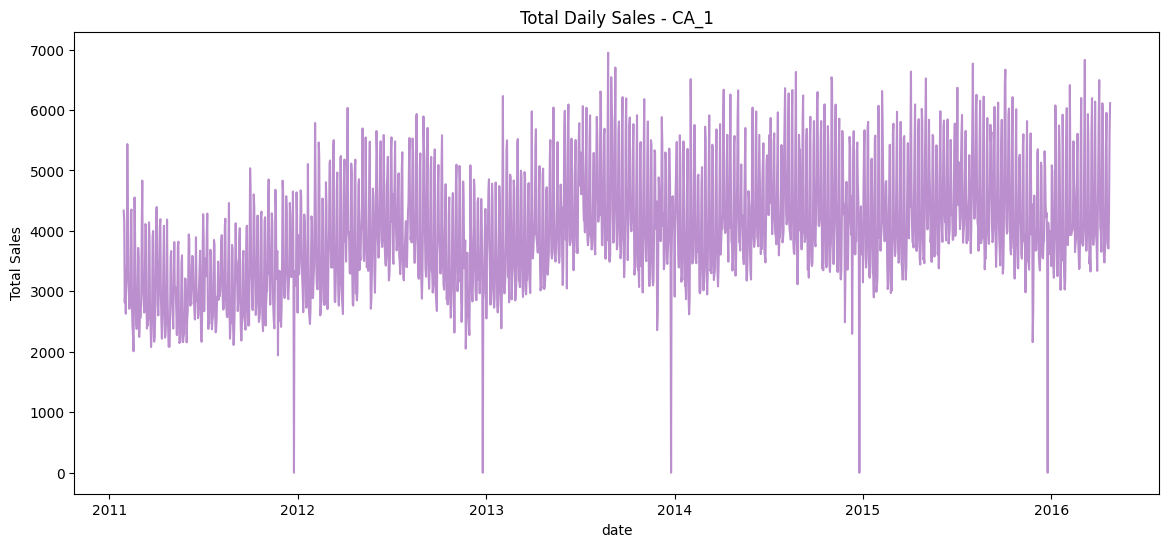

In [17]:
# Ventas totales por dia 
daily_sales = cal_sal.groupby("date")['sales'].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["date"], daily_sales["sales"], color='#BB8FCE')
plt.title("Total Daily Sales - CA_1")
plt.xlabel("date")
plt.ylabel("Total Sales")
plt.show()

Se mantiene bastante bien entre los años, pero tenemos una caida debajo de 1000 y quiero ver que día 

In [18]:
# viendo los dias que estan en cero en la grafica
daily_sales[daily_sales["sales"] < 500]

,date,sales
330,2011-12-25,0
696,2012-12-25,0
1061,2013-12-25,0
1426,2014-12-25,0
1791,2015-12-25,0


Vemos que los dias 25 de diciembre no se abre tienda por eso las ventas son 0

In [19]:
# para que el bar chart salga en orden de dia de las semanas
dow_sales = cal_sal.groupby("weekday")["sales"].mean().reset_index()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_sales["weekday"] = pd.Categorical(dow_sales["weekday"], categories=order, ordered=True)
dow_sales = dow_sales.sort_values("weekday")

/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_45058/139742631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_sales, x="weekday", y="sales", palette='flare')


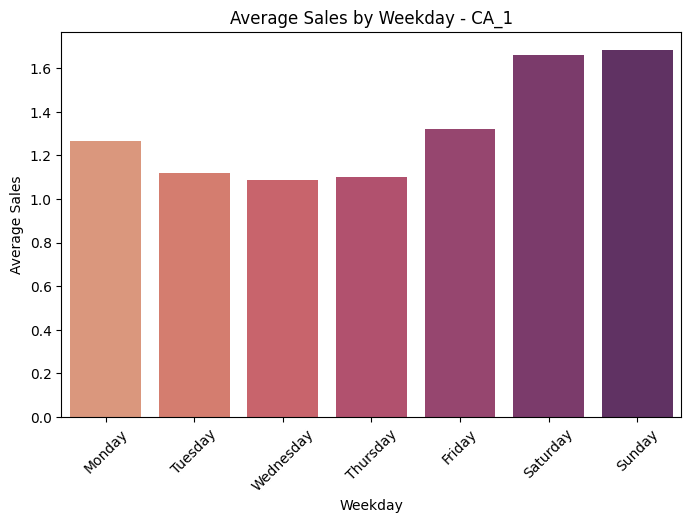

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=dow_sales, x="weekday", y="sales", palette='flare')
plt.xticks(rotation=45)
plt.title("Average Sales by Weekday - CA_1")
plt.xlabel("Weekday")
plt.ylabel("Average Sales")
plt.show()

* Ventas más bajas martes-jueves
* Incremento viernes
* Pico claro sábado y domingo 

La diferencia no es enorme, pero sí consistente. 

## Revisión de sell_prices

In [21]:
sell_prices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


## Merge entre cal_sal y sell_prices -> df_total

In [22]:
df_total = cal_sal.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left")

### Revisión de datos nulos, duplicados 

In [23]:
df_total['sell_price'].isnull().sum()

1129842

In [24]:
df_total["sell_price"].isnull().mean()

0.19370700239013006

##### Saber desde que fecha estan los nulos 

In [25]:
# ver cuando aparecen los nulos 
df_total[df_total["sell_price"].isnull()]["date"].min(), df_total[df_total["sell_price"].isnull()]["date"].max()

#los nulos aparecen desde el inicio de fecha del dataset, hasta casi el final del dataset

(Timestamp('2011-01-29 00:00:00'), Timestamp('2016-02-12 00:00:00'))

- Algunos productos entran al catálogo más tarde
- Algunos productos salen antes
- No todos están activos al mismo tiempo

In [26]:
# Me quedo solo con las filas donde el sell_price no sea nulo, además era solo un 19% de datos 
df_total = df_total[df_total["sell_price"].notnull()]

In [27]:
print(df_total.shape)
df_total["sell_price"].isnull().sum()

(4702895, 23)


0

In [28]:
df_total

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event,sell_price
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0,0.46
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0,1.56
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0,3.17
11,HOBBIES_1_012_CA_1_validation,HOBBIES_1_012,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0,5.98
14,HOBBIES_1_015_CA_1_validation,HOBBIES_1_015,HOBBIES_1,HOBBIES,CA_1,CA,d_1,4,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832732,FOODS_3_823_CA_1_validation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1913,1,2016-04-24,11613,...,2016,NaN,NaN,NaN,NaN,0,0,0,0,2.98
5832733,FOODS_3_824_CA_1_validation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,2016,NaN,NaN,NaN,NaN,0,0,0,0,2.48
5832734,FOODS_3_825_CA_1_validation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1913,2,2016-04-24,11613,...,2016,NaN,NaN,NaN,NaN,0,0,0,0,3.98
5832735,FOODS_3_826_CA_1_validation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,2016,NaN,NaN,NaN,NaN,0,0,0,0,1.28


In [29]:
# Crear deciles porque estos esta función divide por cantidad de datos iguales 
# porque quiero separarlo por rango de precio de los productos a ver avg de ventas
price_bins = pd.qcut(df_total["sell_price"], q=10)

In [30]:
#Calcular la media para cada decil 
price_sales = (df_total.groupby(price_bins)["sales"].mean().reset_index())

#cambiando el nombre de sus columnas para mejor entendimiento
price_sales.columns = ["price_range", "avg_sales"]
price_sales

/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_45058/1387037548.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_sales = (df_total.groupby(price_bins)["sales"].mean().reset_index())


,price_range,avg_sales
0,"(0.009000000000000001, 1.25]",4.078003
1,"(1.25, 1.98]",2.816888
2,"(1.98, 2.48]",1.559300
3,"(2.48, 2.94]",1.427131
4,"(2.94, 3.47]",1.663501
5,"(3.47, 3.98]",1.240670
6,"(3.98, 4.97]",0.835734
7,"(4.97, 6.24]",0.979203
8,"(6.24, 8.64]",0.701056
9,"(8.64, 30.98]",0.629213


In [32]:
# Formatear intervalos a dos decimales
price_sales["price_range"] = price_sales["price_range"].apply(
    lambda x: f"{x.left:.2f} - {x.right:.2f}"
)

/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_45058/998705360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_sales, x="price_range", y="avg_sales", palette="flare")


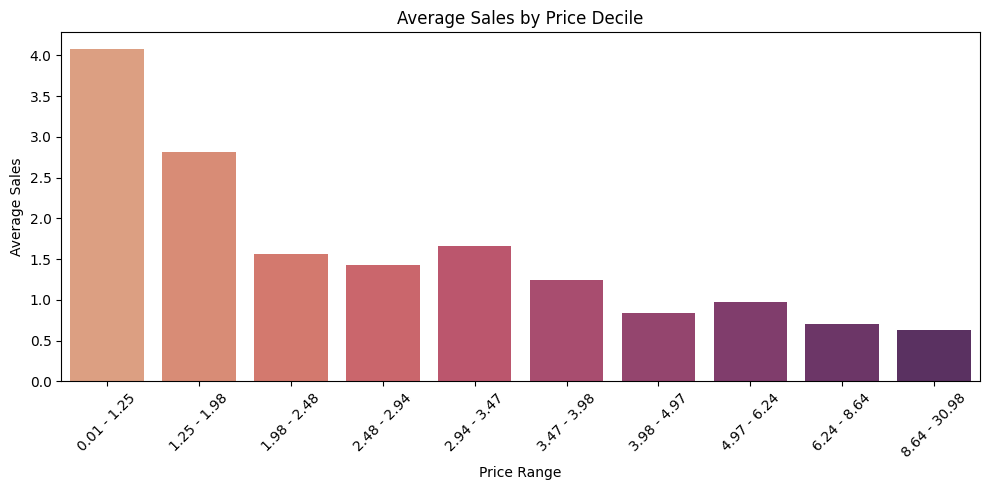

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(data=price_sales, x="price_range", y="avg_sales", palette="flare")

plt.xticks(rotation=45)
plt.title("Average Sales by Price Decile")
plt.xlabel("Price Range")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Análisis por categoría

In [34]:
cat_sales = df_total.groupby("cat_id")["sales"].mean().reset_index()
cat_sales

,cat_id,sales
0,FOODS,2.423791
1,HOBBIES,1.004284
2,HOUSEHOLD,0.894878


/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_45058/1697286668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x="cat_id", y="sales", palette="flare")


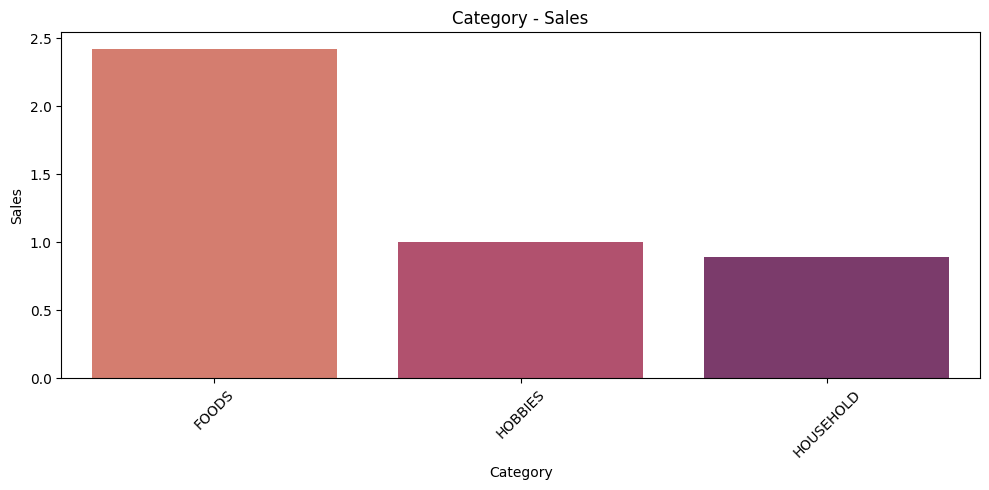

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(data=cat_sales, x="cat_id", y="sales", palette="flare")

plt.xticks(rotation=45)
plt.title("Category - Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

#### Análisis por producto (variabilidad)

In [36]:
variabilidad = df_total.groupby("item_id")["sales"].std().describe()
variabilidad

count    3049.000000
mean        1.765252
std         2.402427
min         0.176936
25%         0.722471
50%         1.136154
75%         1.826411
max        57.862321
Name: sales, dtype: float64

Hay productos más volátiles?

1. Media ~ 1.76 
y la desviación estandar es de 2.40, cada producto tiene una desviación estándar de 1.76 unidades\
eso indica variabilidad moderada.

2. Mediana ~ 1.13
La mitad de los productos tienen volatilidad baja\
Muchos productos son relativamente estables.

3. Máximo - 57.86 
Hay productos extremadamente volátiles 
probablemente por:
* Productos con promociones fuertes
* Productos muy demandados
* Productos con comportamiento irregular 

Pare evaluar mejor la volatilidad vamos a usar el Coeficiente de Variación

CV = std/mean

In [37]:
item_stats = df_total.groupby("item_id")["sales"].agg(["mean","std"])
item_stats["cv"] = item_stats["std"] / item_stats["mean"]

item_stats["cv"].describe()

count    3049.000000
mean        1.706199
std         0.753085
min         0.357784
25%         1.188094
50%         1.535636
75%         2.055659
max         7.445246
Name: cv, dtype: float64

1. Media ~ 1.70 
En promedio, la desviación estándar es 1.7 veces la media. Eso es bastante alto.\
La demanda es altamente variable en muchos productos 

* el std ~ 0.75 no es la volatilidad de ventas. Es variabilidad en la volatilidad entre productos.

2. Mediana ~ 1.53 
La mitad de los productos tienen: Volatilidad mayor a su media.\
Hay ruido 

3. Máximo = 7.44 

#### Visualización por producto individual

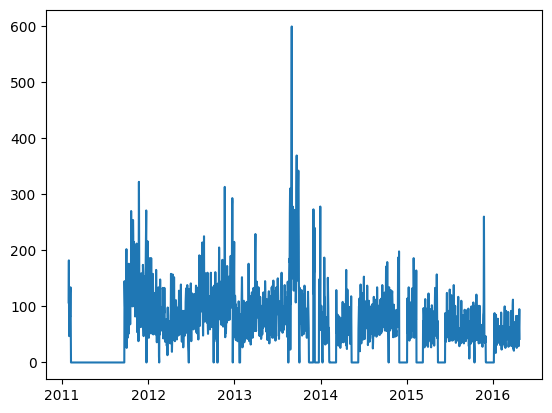

In [38]:
sample_item = df_total[df_total["item_id"] == "FOODS_3_090"]

plt.plot(sample_item["date"], sample_item["sales"])

#### Conclusiones:

1. La demanda es altamente intermitente (63% ceros).
2. Existe estacionalidad semanal clara.
3. Hay heterogeneidad significativa entre productos.
4. Algunos productos presentan alta volatilidad (CV > 1).
5. El precio muestra relación agregada con ventas.
6. Eventos especiales pueden afectar demanda.
7. La serie presenta outliers fuertes.

## ¿Cómo impacta esto en decisiones de inventario?

### KPI 1 - Intermittency Rate
Con qué frecuencia un producto se queda en 0 ventas.\
Mide qué tan irregular es la demanda de un producto, mostrando cuántos días no registra ventas.

In [39]:
# primero quiero ver que porcentaje total de observaciones son 0?
intermittency_global = (df_total["sales"] == 0).mean() * 100
print(intermittency_global)

55.28590368273159


In [40]:
# quiero ver la tasa o proporcion de intermitencia de un producto  
intermittency_item = (df_total.groupby("item_id")['sales'].apply(lambda x: (x == 0).mean()*100).reset_index())
intermittency_item.columns = ['item_id', 'intermittency_rate']
intermittency_item

,item_id,intermittency_rate
0,FOODS_1_001,56.351281
1,FOODS_1_002,66.806064
2,FOODS_1_003,52.848928
3,FOODS_1_004,14.332893
4,FOODS_1_005,53.842133
...,...,...
3044,HOUSEHOLD_2_512,59.905907
3045,HOUSEHOLD_2_513,53.339350
3046,HOUSEHOLD_2_514,74.281234
3047,HOUSEHOLD_2_515,88.479810


In [41]:
# y calculo el promedio de intermitencia 
mean_inter = intermittency_item["intermittency_rate"].mean() 
mean_inter

55.90176959658236

In [42]:
# Clasificacion de la intermitencia de un producto 
def classify(rate):
    if rate > 0.7:
        return "High Intermittency"
    elif rate > 0.4:
        return "Medium Intermittency"
    else:
        return "Low Intermittency"

intermittency_item["segment"] = intermittency_item["intermittency_rate"].apply(classify)

In [43]:
intermittency_item["segment"].value_counts()

segment
High Intermittency      3039
Low Intermittency          5
Medium Intermittency       5
Name: count, dtype: int64

Hipótesis:\
“La demanda es altamente intermitente.”

KPI:\
Intermittency Rate = 55.90% 

Alta intermitencia implica:
* Mayor dificultad de forecasting.
* Mayor riesgo de sobrestock.

Impacto negocio:\
Ayuda a identificar productos que requieren estrategias de reposición más conservadoras.

### KPI 2 - Los productos presentan alta Volatilidad (CV) 
Coeficiente de variación por producto.\
Permite segmentar productos en:
* Estables → reposición automática.
* Volátiles → monitoreo especial.

In [44]:
# calculamos la media 
item_stats = df_total.groupby("item_id")['sales'].agg(['mean', 'std']).reset_index()
item_stats

,item_id,mean,std
0,FOODS_1_001,0.785677,1.258055
1,FOODS_1_002,0.477784,0.803791
2,FOODS_1_003,0.832201,1.163230
3,FOODS_1_004,10.433950,8.753203
4,FOODS_1_005,1.162572,2.015686
...,...,...,...
3044,HOUSEHOLD_2_512,0.686357,1.136549
3045,HOUSEHOLD_2_513,0.861913,1.239909
3046,HOUSEHOLD_2_514,0.303189,0.559321
3047,HOUSEHOLD_2_515,0.136580,0.406974


In [45]:
#para evitar dimensiones porque la media puede ser muy cercana a 0 de algunos productos
item_stats = item_stats[item_stats["mean"] > 0]

In [46]:
# Vamos a calcular el coeficiente de variación
item_stats["cv"] = item_stats["std"] / item_stats["mean"]
item_stats['cv'].describe()

count    3049.000000
mean        1.706199
std         0.753085
min         0.357784
25%         1.188094
50%         1.535636
75%         2.055659
max         7.445246
Name: cv, dtype: float64

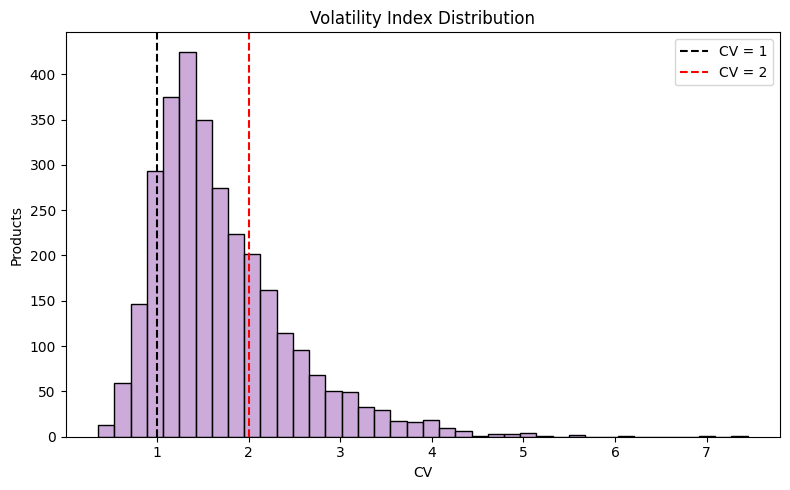

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(item_stats["cv"], bins=40, color="#BB8FCE")
plt.axvline(1, color="black", linestyle="--", label="CV = 1")
plt.axvline(2, color="red", linestyle="--", label="CV = 2")
plt.legend()
plt.title("Volatility Index Distribution")
plt.xlabel("CV")
plt.ylabel("Products")

plt.tight_layout()
plt.show()

* CV > 1 → demanda más variable que la media.
* CV > 2 → productos altamente volátiles.

La distribución del Volatility Index muestra que la mayoría de los productos presentan variabilidad significativa (CV > 1), con una cola larga de productos altamente volátiles (CV > 2). 

In [48]:
#Clasificar productos
def classify_volatility(cv):
    if cv > 2:
        return "High Volatility"
    elif cv > 1:
        return "Medium Volatility"
    else:
        return "Low Volatility"

item_stats["volatility_segment"] = item_stats["cv"].apply(classify_volatility)

In [49]:
item_stats["volatility_segment"].value_counts()

volatility_segment
Medium Volatility    1836
High Volatility       832
Low Volatility        381
Name: count, dtype: int64

Hipótesis:\
"Los productos presentan alta volatilidad"

KPI:\
CV medio ≈ 1.7

El volatility Index (CV) permite identificar productos con alta variabilidad relativa, los cuales requieren estrategias de reposición más conservadoras monitoreo continuo.

### KPI 3 - Las Ventas Aumentan el fin de semana 
Incremento porcentual de ventas en fin de semana respecto a días laborales.\
Indica estacionalidad semanal.\
Permite ajustar inventario antes del sábado.

In [50]:
# crearmos variable weekend -> fin de semana
df_total["is_weekend"] = df_total["weekday"].isin(["Saturday", "Sunday"])

In [51]:
# calculamos promedio de vendas
weekend_sales = df_total.groupby("is_weekend")["sales"].mean()
weekend_sales

is_weekend
False    1.462040
True     2.072108
Name: sales, dtype: float64

* False -> promedio Lunes-Viernes
* True -> promedio sábado-domingo

In [52]:
# calculando el lift 
weekday_avg = weekend_sales[False] #dia de semana 
weekend_avg = weekend_sales[True] # fin de semana 

weekend_lift = (weekend_avg - weekday_avg) / weekday_avg

print("Weekend Sales Lift:", weekend_lift) #incremento relativo 
print("En porcentaje:", weekend_lift * 100) # aumento relativo comparado con la base

Weekend Sales Lift: 0.417271578655165
En porcentaje: 41.7271578655165


Hipótesis:\
“Las ventas suben en fin de semana.”

KPI:\
Weekend Lift = +41.7%

Un aumento del 41.7% implica:
* La demanda cambia significativamente cada semana.
* El inventario debe ajustarse antes del sábado.
* No considerar este efecto generaría roturas de stock.

El análisis revela un incremento del 41.7% en ventas durante el fin de semana, indicando un patrón estacional semanal fuerte que debe incorporarse en la planificación de inventario y en el modelo predictivo.

### KPI 4 - La demanda es sensible al precio
 
Relación entre deciles de precio y ventas promedio.\
Sirve para entender elasticidad agregada.

In [53]:
df_elasticity = df_total.copy()

In [54]:
# Eliminar ventas = 0 porque log(0) no existe
df_elasticity = df_elasticity[df_elasticity["sales"] > 0]

# Eliminamos precios 0 por si hubo algun error
df_elasticity = df_elasticity[df_elasticity["sell_price"] > 0]

In [55]:
# creacio de variables log 
df_elasticity["log_sales"] = np.log(df_elasticity["sales"])
df_elasticity["log_price"] = np.log(df_elasticity["sell_price"])

In [56]:
#estimanos elasticidad por categoría
elasticities = {}

for cat in df_elasticity["cat_id"].unique():
    df_cat = df_elasticity[df_elasticity["cat_id"] == cat]
    
    # Solo si hay suficiente variación
    if df_cat["sell_price"].nunique() > 1:
        
        X = sm.add_constant(df_cat["log_price"])
        y = df_cat["log_sales"]
        
        model = sm.OLS(y, X).fit()
        elasticities[cat] = model.params["log_price"]

elasticities

{'HOBBIES': -0.3104232781501248,
 'HOUSEHOLD': -0.31143920430469313,
 'FOODS': -0.44580281494692586}

In [57]:
elasticity_df = pd.DataFrame(
    elasticities.items(),
    columns=["category", "price_elasticity"])
elasticity_df

,category,price_elasticity
0,HOBBIES,-0.310423
1,HOUSEHOLD,-0.311439
2,FOODS,-0.445803


Hipótesis:\
“La demanda es sensible al precio.”

KPI:\
Elasticidad = -0.45 -> FOODS

Elasticidad < -1 → demanda elástica (muy sensible)\
Elasticidad ≈ -1 → elasticidad unitaria\
Elasticidad > -1 → demanda inelástica

Todas están entre 0 y -1. -> Demanda inelástica.\
Un aumento del 1% en precio reduce ventas menos de 1%.

FOODS = -0.45:\
Si el precio sube 10%\
Las ventas bajan aproximadamente 4.5%.

In [58]:
df_total.to_csv("../processed/df_total_clean_CA1.csv", index=False)

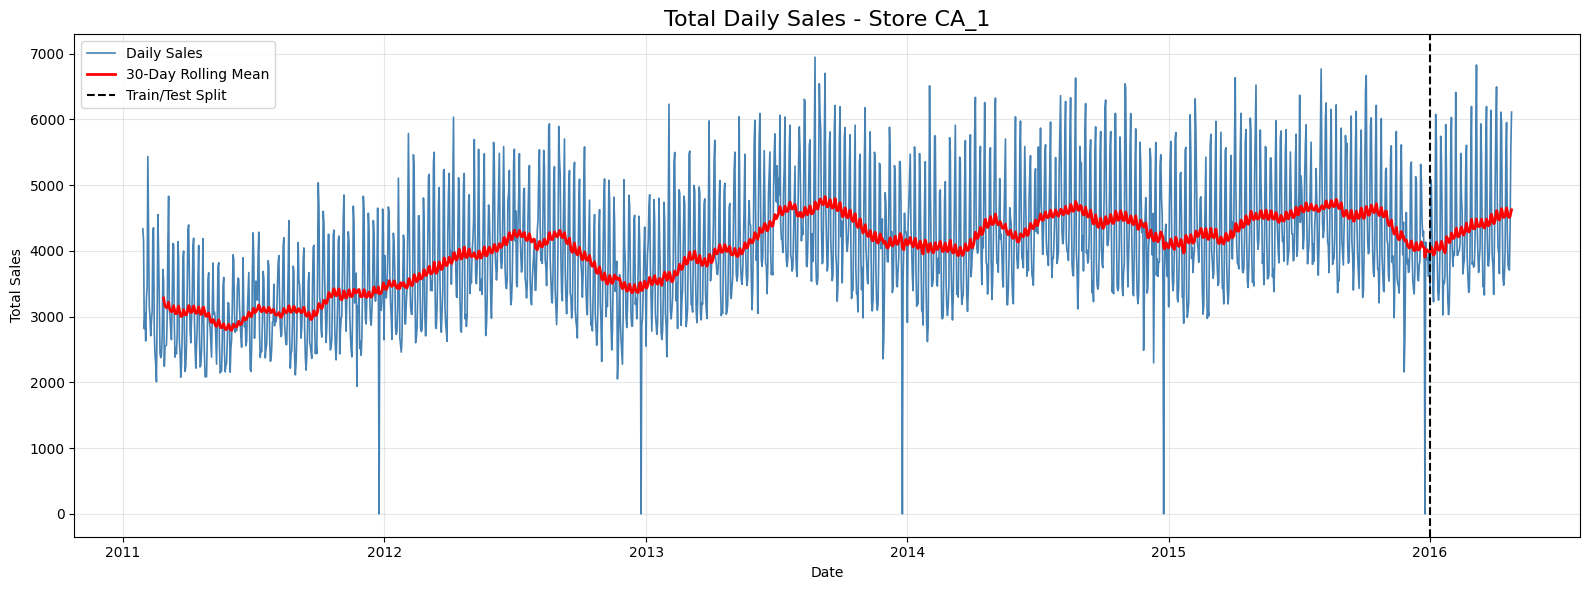

In [59]:
# para feature engineering
plt.figure(figsize=(16,6))

# Línea principal
plt.plot(daily_sales["date"], daily_sales["sales"], 
         color="steelblue", 
         linewidth=1.2, 
         label="Daily Sales")

# Rolling mean 30 días para tendencia
rolling_30 = daily_sales["sales"].rolling(30).mean()
plt.plot(daily_sales["date"], rolling_30, 
         color="red", 
         linewidth=2, 
         label="30-Day Rolling Mean")

# Línea vertical para split temporal (ejemplo)
plt.axvline(pd.to_datetime("2016-01-01"), 
            color="black", 
            linestyle="--", 
            label="Train/Test Split")

plt.title("Total Daily Sales - Store CA_1", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()